原始数据点数: 2000
删除数据点数: 100
剩余数据点数: 1900


<Axes: xlabel='time'>

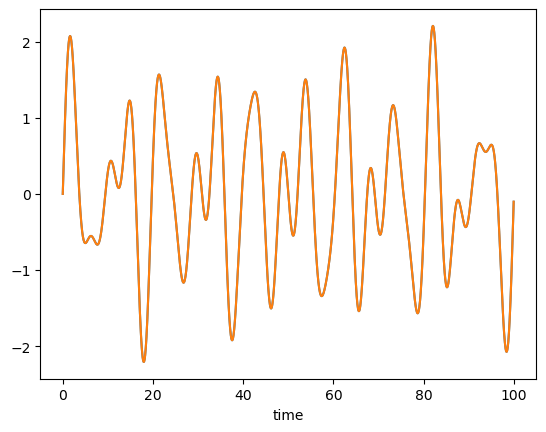

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1. 采样参数 ----------
dt = 0.05              # 时间间隔 0.05s
duration = 100          # 信号时长（秒）
t = np.arange(0, duration, dt)

# ---------- 2. 三个频率成分叠加 ----------
f1, f2, f3 = 0.1, 0.15, 0.21
A1, A2, A3 = 1.0, 0.8, 0.5

signal = (A1 * np.sin(2 * np.pi * f1 * t)
          + A2 * np.sin(2 * np.pi * f2 * t)
          + A3 * np.sin(2 * np.pi * f3 * t))

# 构造 pandas 对象，时间作为索引
s = pd.Series(signal, index=pd.Index(t, name="time"), name="signal")
s_original = s.copy()          # 备份原始信号，用于绘图对比

#plt.plot(s['time'],s['signal'])
s.plot()

# ---------- 3. 随机删除 100 行 ----------
n_drop = 100
rng = np.random.default_rng(seed=42)   # 固定种子，结果可复现

# 用位置索引随机抽取要删除的行，避免浮点时间索引匹配问题
drop_pos = rng.choice(len(s), size=n_drop, replace=False)
drop_idx = s.index[drop_pos]

s_drop = s.drop(drop_idx)      # 删除后得到新对象，原 s 不变

print("原始数据点数:", len(s))
print("删除数据点数:", n_drop)
print("剩余数据点数:", len(s_drop))

s_drop.plot()

In [24]:
s_drop.describe()

count    1900.000000
mean       -0.004269
std         0.971722
min        -2.204901
25%        -0.645407
50%        -0.005295
75%         0.643170
max         2.204901
Name: signal, dtype: float64

In [28]:
# 现在s_drop看上去跟之前差不多，但是缺少了不少数据
# 1）找出缺失的点在哪里，并输出缺失点对应时间（前提并不知道有多少点缺失）
# 2）用不少2两种方法，补全数据

In [26]:
# 3) 推荐一种方法，看看适合于缺失点数最大上限是多少？请用程序多次尝试后给出最优方案
# 提示，改变上面n_drop,看看你的算法随着缺失点增加，是否仍然可靠